# Internet Of Things: second challenge part one
 
## Authors
- Lorenzo Bardelli: 10831941
- Pietro Pizzoccheri (Team Leader): 10797420

Packets have been analyzed using Wireshark through tshark terminal interface in order to exploit advanced filtering and sorting through command line

## Notes
- Reference document: Challenge2.pdf
- Malformed packets are ignored as requested by the challenge

## CQ1
**Questions:** 
- CQ1a) Find all NON Confirmable DELETE requests directed to the coap.me
server that received a successful response.
Take note of the MID of such requests

- CQ1b) How many of the requests found in point CQ1a) actually obtained the
desired outcome?

**answer**
- CQ1a (MID list): `30800`
- CQ1b (count): `1`

**Commands used :**
```bash
#from the challenge2 folder
mkdir -p CQ1

#NON DELETE requests to coap.me (MID + token)
tshark -r A.pcapng -Y "coap.type == 1 && coap.code == 4 && ip.dst == 134.102.218.18" -T fields -e coap.mid -e coap.token > CQ1/delete_requests.txt
echo "delete requests:"
cat CQ1/delete_requests.txt

#successful DELETE responses (2.02 Deleted = 66 && 4.04 Not Found = 132), server successfully answered to the request
tshark -r A.pcapng -Y "coap.code == 66 || coap.code == 132 && ip.src == 134.102.218.18" -T fields -e coap.token > CQ1/success_tokens.txt
echo "success tokens:"
cat CQ1/success_tokens.txt

#keep only requests whose token appears in successful responses
grep -F -f CQ1/success_tokens.txt CQ1/delete_requests.txt | sort -u > CQ1/matching_requests.txt
echo "matching requests:"
cat CQ1/matching_requests.txt

#CQ1a and CQ1b
echo "CQ1a MIDs:"
awk '{print $1}' CQ1/matching_requests.txt
echo "CQ1b count:"
wc -l CQ1/matching_requests.txt
```
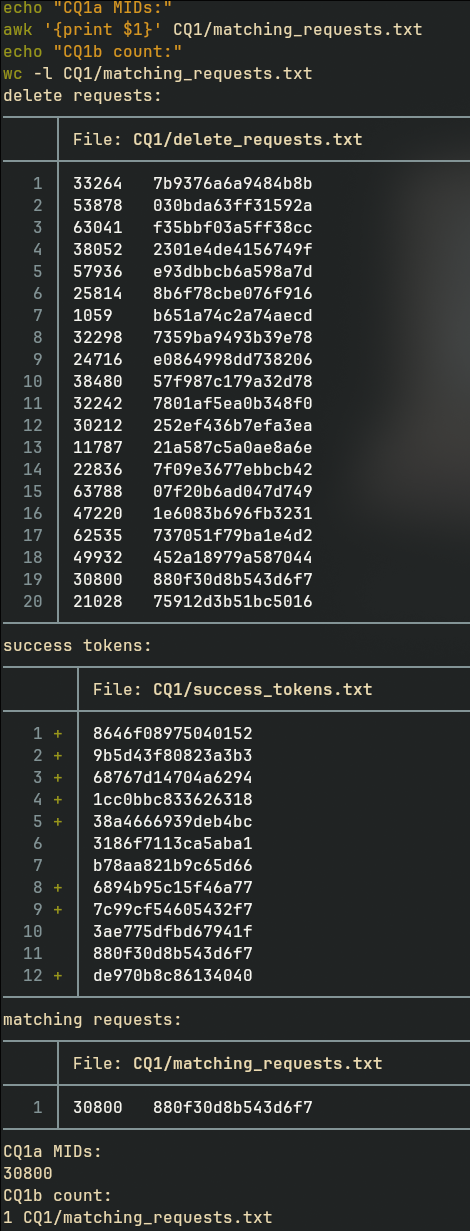


## CQ2
**Question:** How many CoAP resources in the local server received the same
number of unique unsuccessful Confirmable POST and PUT requests?
Assuming a resource receives X different CON unsuccessful POST requests and Y different
CON unsuccessful PUT requests, how many resources have X=Y, with X>0?
!! Consider unsuccessful only if there is a response stating it is not successful !

**answer:**
- Count: `1`
- Resource: `/dining_room`

**Command used:**
```bash

mkdir -p CQ2

#error response MIDs from local CoAP server
tshark -r A.pcapng -Y "coap.code >= 128 && ip.src == 127.0.0.1" -T fields -e coap.mid | sort -u > CQ2/error_mids.txt
echo "error mids count:"
wc -l CQ2/error_mids.txt
echo "sample error mids:"
head -n 20 CQ2/error_mids.txt

#all CON POST and CON PUT requests to local server
tshark -r A.pcapng -Y "coap.type == 0 && coap.code == 2 && ip.dst == 127.0.0.1" -T fields -e coap.mid -e coap.opt.uri_path > CQ2/post_requests.txt
tshark -r A.pcapng -Y "coap.type == 0 && coap.code == 3 && ip.dst == 127.0.0.1" -T fields -e coap.mid -e coap.opt.uri_path > CQ2/put_requests.txt
echo "post requests count:"
wc -l CQ2/post_requests.txt
echo "put requests count:"
wc -l CQ2/put_requests.txt

#keep only failed requests (MID present in error list)
grep -F -f CQ2/error_mids.txt CQ2/post_requests.txt | sort -u > CQ2/failed_post_unique.txt
grep -F -f CQ2/error_mids.txt CQ2/put_requests.txt | sort -u > CQ2/failed_put_unique.txt
echo "failed POST unique count:"
wc -l CQ2/failed_post_unique.txt
echo "failed PUT unique count:"
wc -l CQ2/failed_put_unique.txt

#count failures per resource
awk '{print $2}' CQ2/failed_post_unique.txt | sort | uniq -c | sed 's/^ *//' | sort -k2 > CQ2/post_counts.txt
awk '{print $2}' CQ2/failed_put_unique.txt | sort | uniq -c | sed 's/^ *//' | sort -k2 > CQ2/put_counts.txt
echo "POST counts:"
cat CQ2/post_counts.txt
echo "PUT counts:"
cat CQ2/put_counts.txt

# keep resources with same POST and PUT failure count (X=Y, X>0)
awk 'NR==FNR{p[$2]=$1; next} ($2 in p && p[$2]==$1 && $1>0){print $1, $2}' CQ2/post_counts.txt CQ2/put_counts.txt > CQ2/matching_resources.txt

#show result and count
echo "matching resources:"
cat CQ2/matching_resources.txt
echo "CQ2 count:"
wc -l CQ2/matching_resources.txt
```
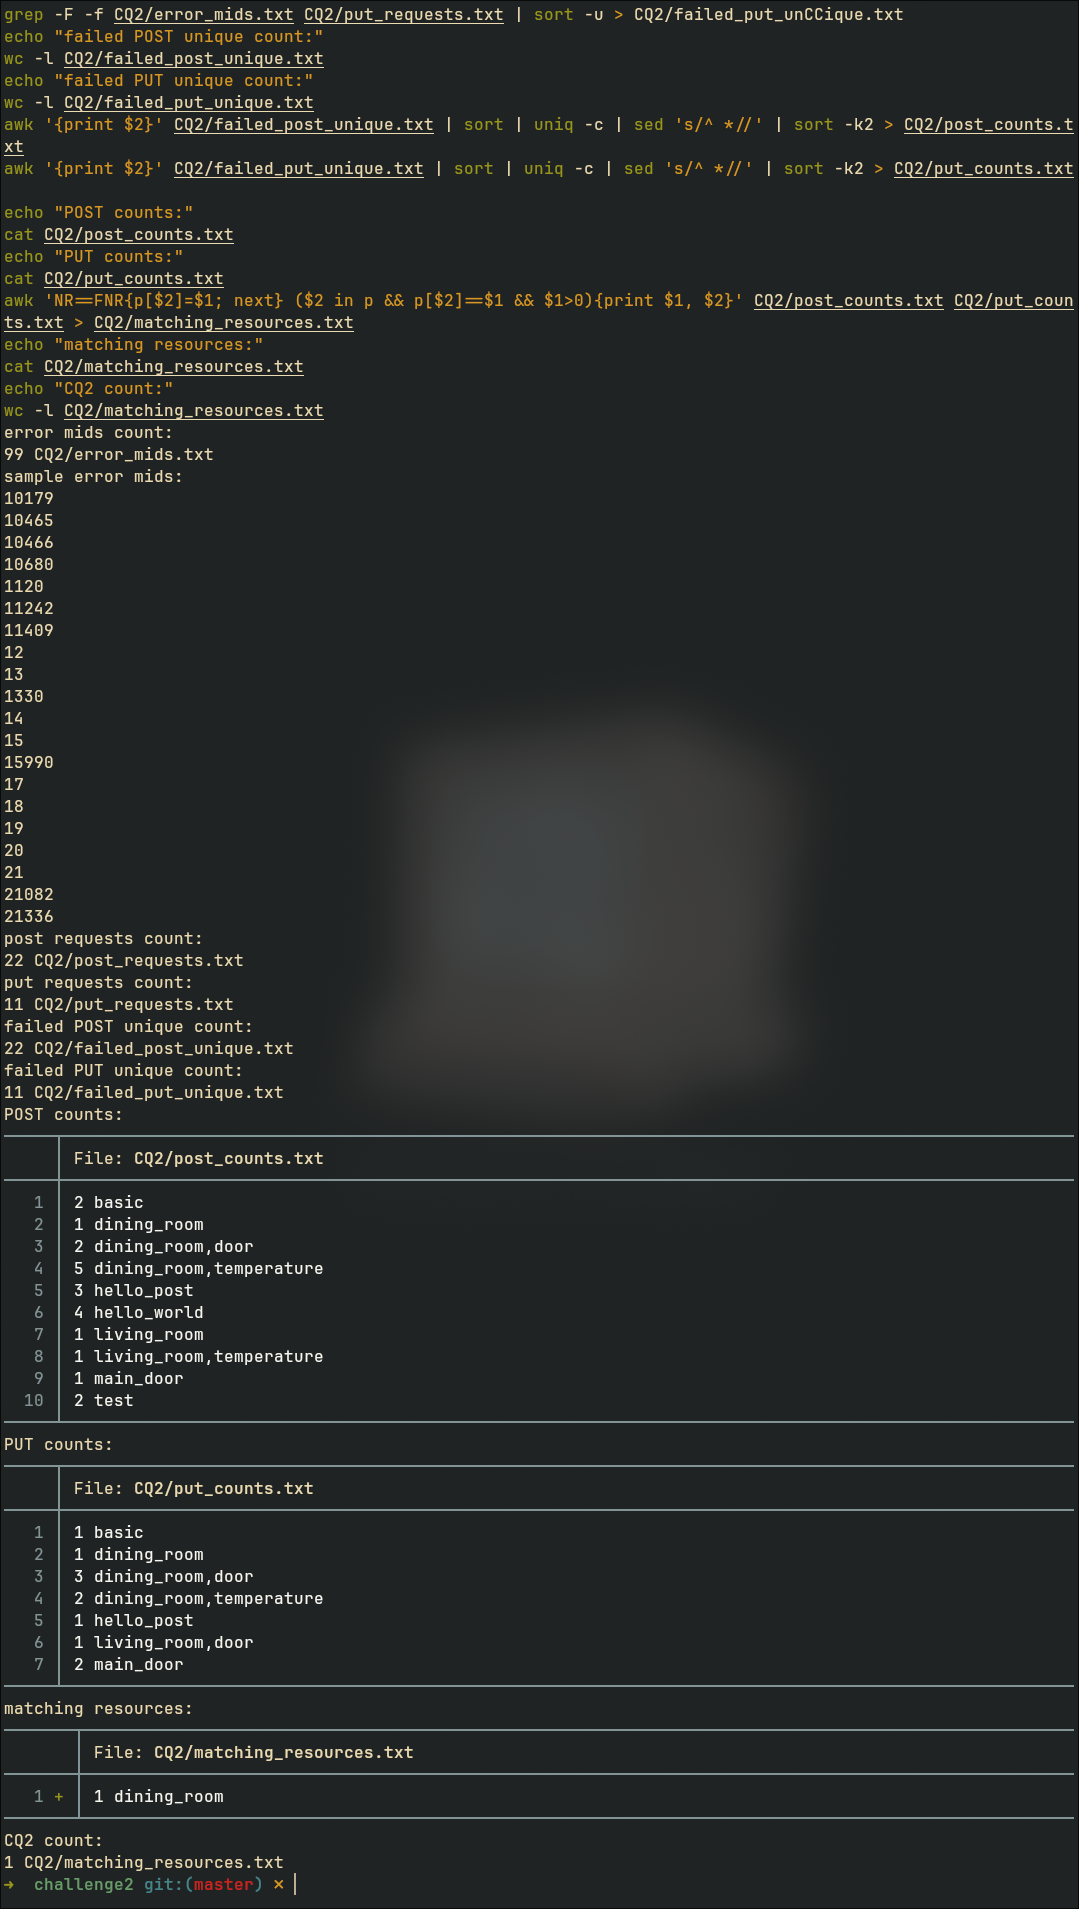

## CQ3
**Questions:** 
- CQ3a) How many separate observe notifications have been sent containing
values for the resource “/dining_room/temperature”, ignoring
retransmissions?

- CQ3b) How many of the notifications found in point CQ3a) are useless (e.g.,
a waste of traffic)?

**answer:**
- CQ3a: `10` separate notifications (retransmissions removed by unique MID), there would be 11 but the first one is an ack
- CQ3b: `0` useless notifications (no unchanged consecutive value among unique notifications), retrtasmissions always fail but we ignore them since we only consider results from CQ3a

every one of the 11 unique notifications contains a temperature value that is different from the notification immediately preceding it. 
because the sensor never transmitted an unchanged value in a new packet, there are 0 useless notifications, only retransmissions.

**Command used:**
```bash
mkdir -p CQ3

# get Observe token for /dining_room/temperature (coap.code==1 = POST, observe==0 = registration, uri_path contains "dining_room" and "temperature")
tshark -r A.pcapng -Y "coap.code==1 && coap.opt.observe==0 && coap.opt.uri_path contains \"dining_room\" && coap.opt.uri_path contains \"temperature\"" -T fields -e coap.token | head -n 1 > CQ3/token.txt
echo "token:"
cat CQ3/token.txt

#extract observe notifications for that token (raw)
TOKEN=$(cat CQ3/token.txt)
# filter by token, observe option presence and code=69 (notification)
tshark -r A.pcapng -Y "coap.token==$TOKEN && coap.code==69 && coap.opt.observe" -T fields -E separator='|' -e frame.number -e coap.mid -e coap.opt.observe -e json.value.string > CQ3/observe_raw.txt
echo "raw notifications count:"
wc -l CQ3/observe_raw.txt
echo "raw notifications sample:"
head -n 25 CQ3/observe_raw.txt

# remove retransmissions (keep first occurrence of each MID)
awk -F'|' '!seen[$2]++' CQ3/observe_raw.txt > CQ3/observe_unique.txt
echo "unique notifications:"
cat CQ3/observe_unique.txt

# CQ3a: count separate notifications
echo "CQ3a count:"
wc -l CQ3/observe_unique.txt

# CQ3b: count useless updates (same value as previous unique update)
awk -F'|' '{split($4,a,","); v=a[2]; if(NR>1 && v==prev) c++; prev=v} END{print c+0}' CQ3/observe_unique.txt > CQ3/useless_count.txt
echo "CQ3b useless count:"
cat CQ3/useless_count.txt
```
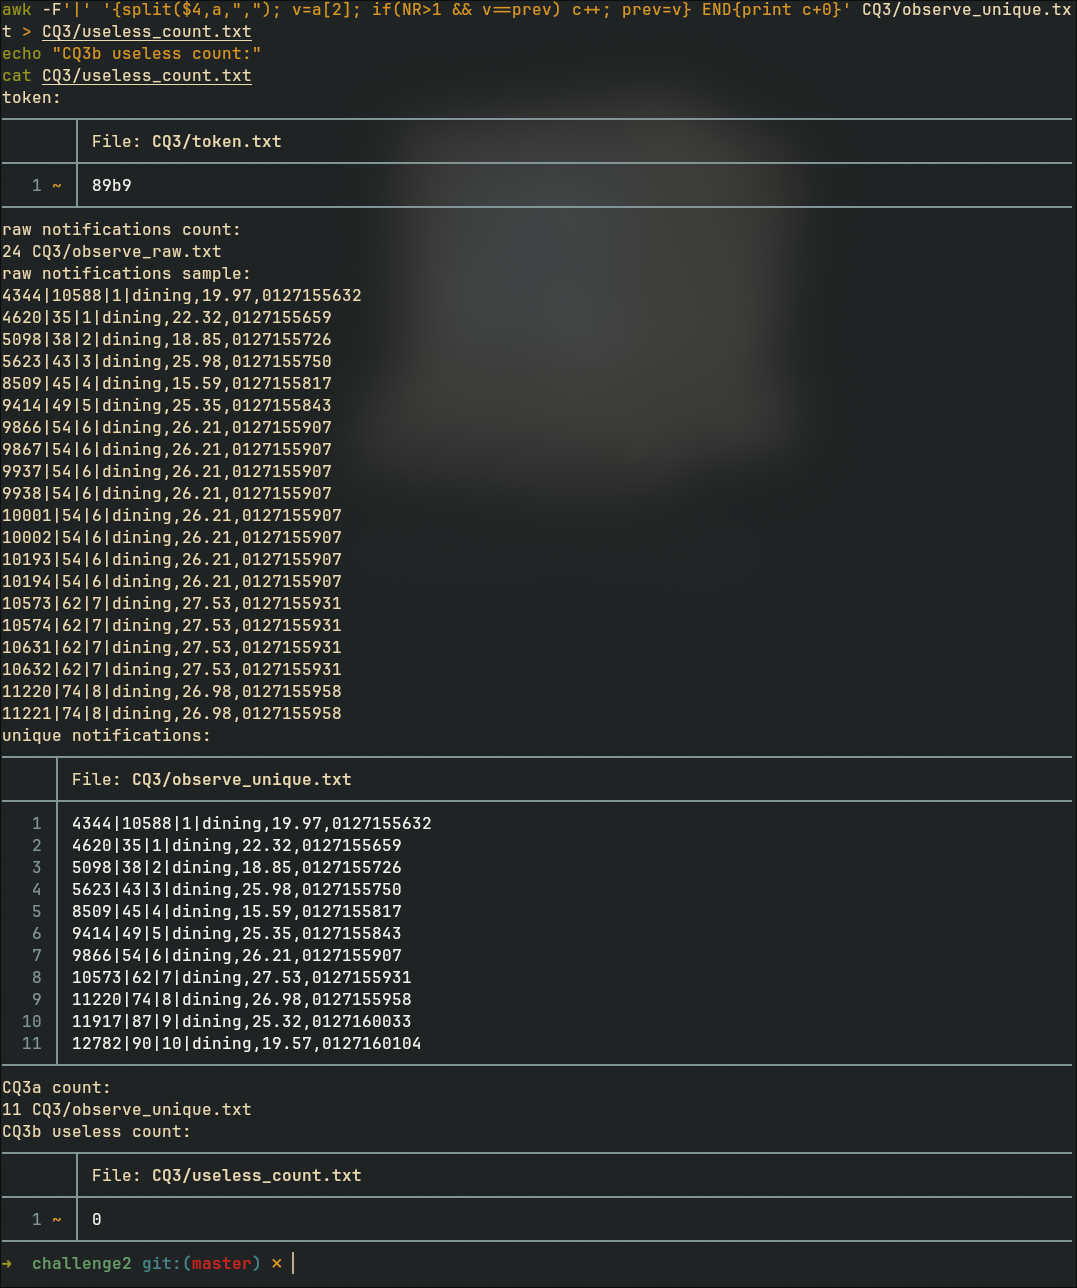
to see only non-retransmitted notifications we can also use wireshark gui like this:

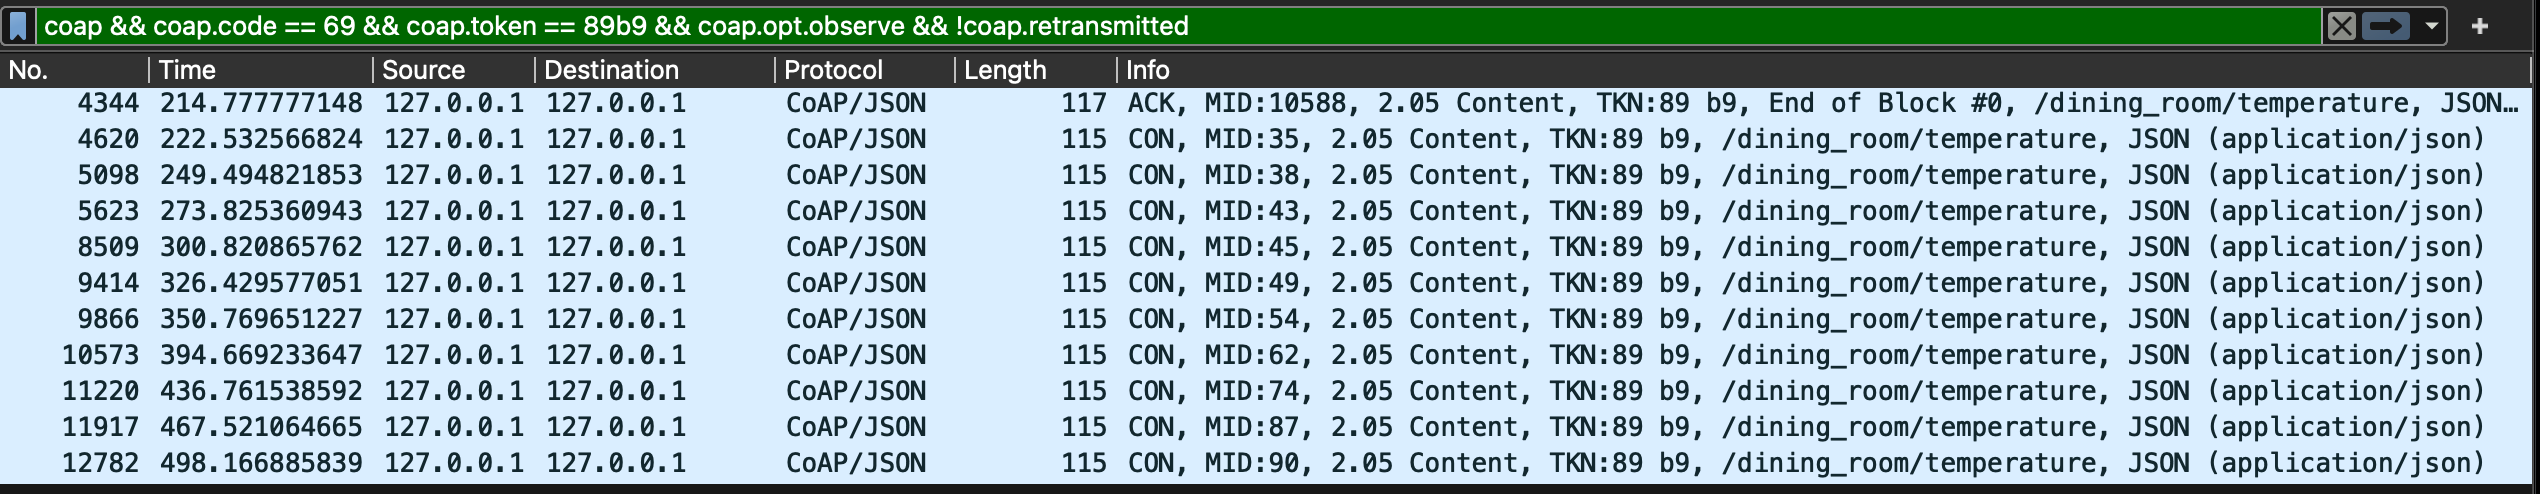

## CQ4
**Question:** 
- CQ4) How many MQTT-SN messages are received by the clients from the
local broker listening on port 1885?
!! Pay attention on the Wireshark port to analyze MQTT-SN packets
(Edit -> Preferences-> Protocols->MQTT-SN)

**answer:** `0`, there are only publish messages followed by destination unreachable messages, so the received messages from the broker to the clients are 0, only messages from clients to broker and error messages from broker to clients are present.

```bash
mkdir -p CQ4

#decode UDP 1885 as MQTT-SN and keep broker->client messages
tshark -r A.pcapng -d udp.port==1885,mqttsn -Y "mqttsn && udp.srcport == 1885" -T fields -e frame.number > CQ4/mqttsn_from_broker.txt
echo "mqttsn messages from broker:"
cat CQ4/mqttsn_from_broker.txt

#count messages
echo "CQ4 count:"
wc -l CQ4/mqttsn_from_broker.txt
```
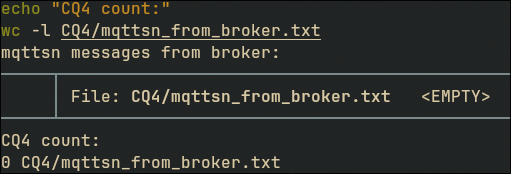

from wireshark gui:

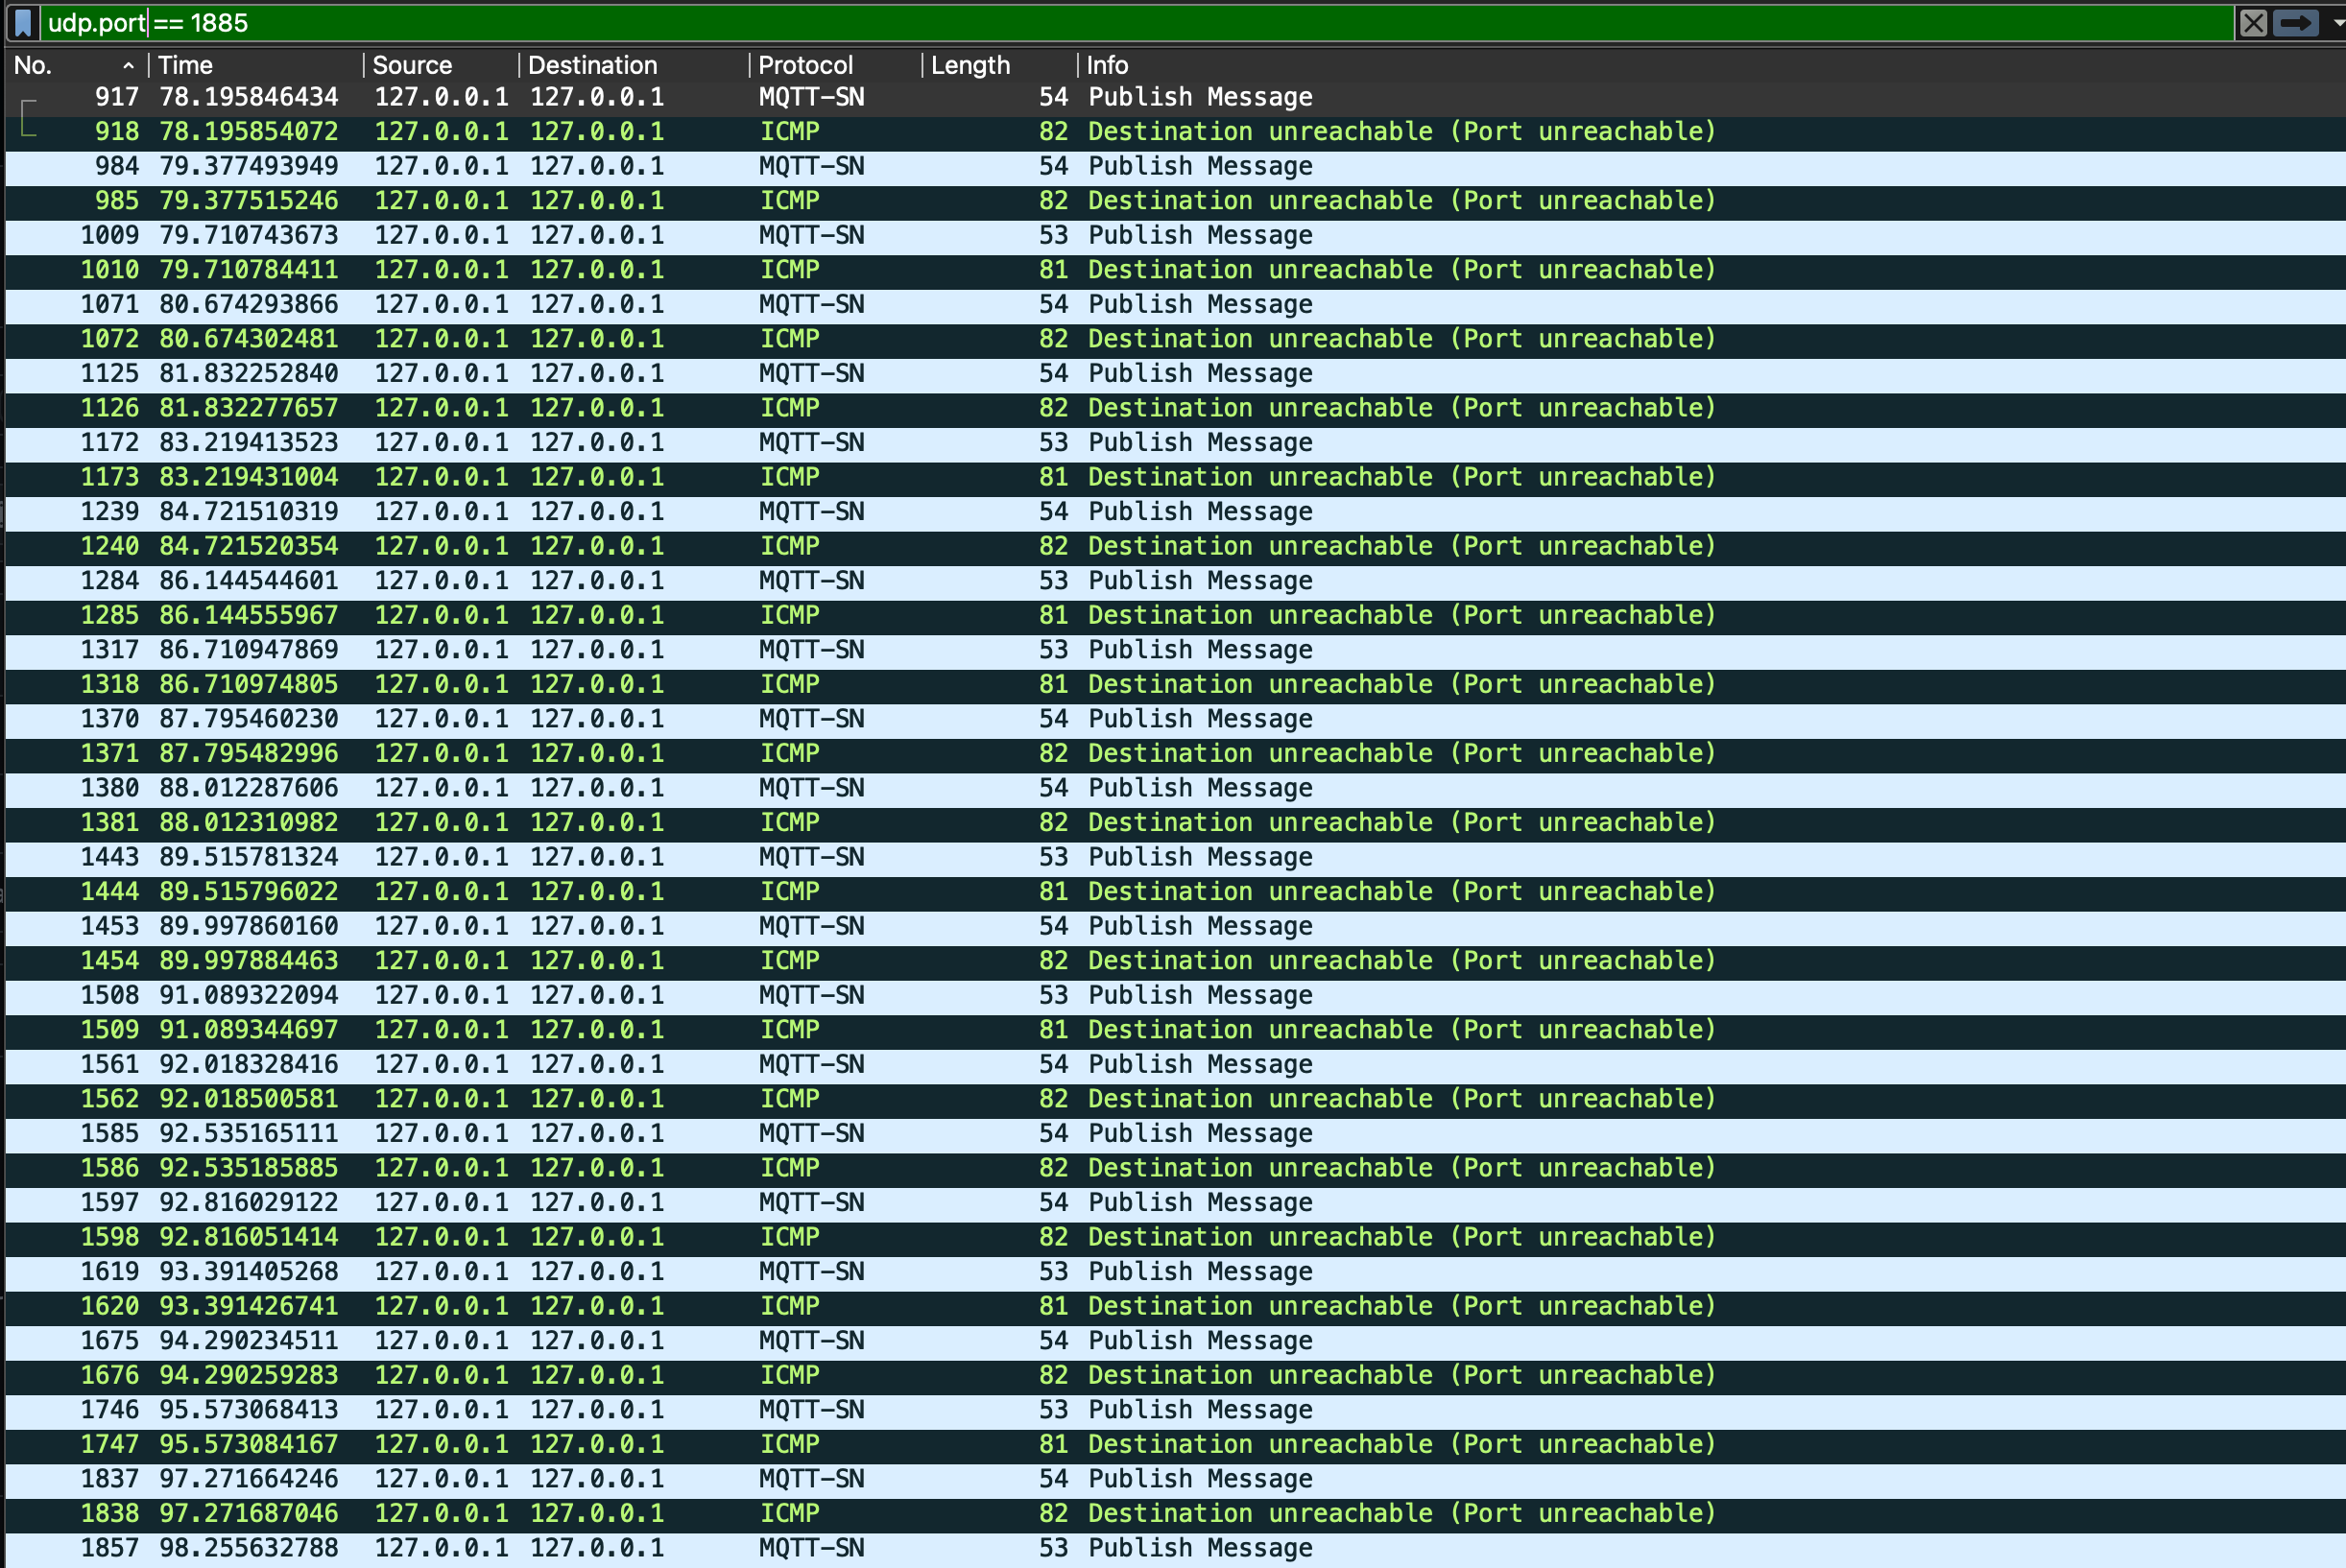

## CQ5
**Question:** How many MQTT subscribers receive a last will message derived from
a subscription that includes atleast one wildcard?

**answer:** `1`
- matching subscriber TCP source port are 3 clients: `51743`, `42777`, `43797`
- matching wildcard subscription: 
    - match found, client 42777 sub 'metaverse/#' matches LWT 'metaverse/room2/floor4'
    - match found, client 42777 sub 'metaverse/#' matches LWT 'metaverse/room2/room2'
    - match found, client 51743 sub 'university/#' matches LWT 'university/department12/room1/temperature'
    - match found, client 43797 sub 'metaverse/#' matches LWT 'metaverse/room2/floor4'
    - match found, client 43797 sub 'metaverse/#' matches LWT 'metaverse/room2/room2'

**Commands used:**
```bash
mkdir -p CQ5

# find Last Will topic (local IPv6 broker traffic)
tshark -r B.pcapng -Y "mqtt.conflag.willflag==1" -T fields -e mqtt.willtopic > CQ5/will_topic.txt
echo "will topic:"
cat CQ5/will_topic.txt

# broker publishes 
tshark -r B.pcapng -Y "mqtt.msgtype==3" -T fields -e tcp.dstport -e mqtt.topic > CQ5/broker_publishes.txt
echo "broker publishes count:"
wc -l CQ5/broker_publishes.txt

# keep only will deliveries (topic matches will topic)
while read -r WILL_TOPIC; do
  echo "Processing WILL_TOPIC: $WILL_TOPIC"
  awk -v t="$WILL_TOPIC" '$2==t {print $1, $2}' CQ5/broker_publishes.txt >> CQ5/will_deliveries.txt
done < CQ5/will_topic.txt
echo "will deliveries:"
cat CQ5/will_deliveries.txt

# extract recipient ports
awk '{print $1}' CQ5/will_deliveries.txt | sort -u > CQ5/recipient_ports.txt
echo "recipient ports:"
cat CQ5/recipient_ports.txt

# get all subscriptions from those recipients
tshark -r B.pcapng -Y "mqtt.msgtype==8" -T fields -e tcp.srcport -e mqtt.topic > CQ5/all_subscriptions.txt
echo "all subscriptions count:"
wc -l CQ5/all_subscriptions.txt

# keep only subscriptions from recipients of will deliveries 
grep -F -f CQ5/recipient_ports.txt CQ5/all_subscriptions.txt > CQ5/recipient_subscriptions.txt
echo "recipient subscriptions:"
cat CQ5/recipient_subscriptions.txt

# keep wildcard subscriptions only
grep -E '[+#]' CQ5/recipient_subscriptions.txt > CQ5/recipient_wildcard_subscriptions.txt
echo "recipient wildcard subscriptions:"
cat CQ5/recipient_wildcard_subscriptions.txt

```

In [15]:
import re

# load the Last Will Topics
with open('../CQ5/will_topic.txt', 'r') as f:
    will_topics = [line.strip() for line in f if line.strip()]

# load the Wildcard Subscriptions
with open('../CQ5/recipient_wildcard_subscriptions.txt', 'r') as f:
    # Split by tab to separate port and topic
    subs = [line.strip().split('\t') for line in f if line.strip()]

matching_clients = set()

#check for matches
for port, sub_topic in subs:
    # MQTT wildcards to regex
    regex_pattern = sub_topic.replace('+', '[^/]+').replace('#', '.*')
    regex_pattern = '^' + regex_pattern + '$'
    
    for will in will_topics:
        if re.match(regex_pattern, will):
            matching_clients.add(port)
            print(f"match found, client {port} sub '{sub_topic}' matches LWT '{will}'")

#print final result
print(f"\nFinal Answer (Total Unique Clients): {len(matching_clients)}")

match found, client 42777 sub 'metaverse/#' matches LWT 'metaverse/room2/floor4'
match found, client 42777 sub 'metaverse/#' matches LWT 'metaverse/room2/room2'
match found, client 51743 sub 'university/#' matches LWT 'university/department12/room1/temperature'
match found, client 43797 sub 'metaverse/#' matches LWT 'metaverse/room2/floor4'
match found, client 43797 sub 'metaverse/#' matches LWT 'metaverse/room2/room2'

Final Answer (Total Unique Clients): 3


## CQ6
**Question:**
- CQ6a) How many different MQTT clients sent atleast one message to erase
a previously retained value in a topic in the public HiveMQ broker?
- CQ6b) How many of the clients found in CQ6a) connected to the HiveMQ
broker with a client identifier strictly longer than 7 bytes (>7)?

**answers:**
- CQ6a: `5`
- CQ6b: `2`

**Command used:**
```bash
mkdir -p CQ6

# find HiveMQ public broker IPs from DNS queries
tshark -r B.pcapng -Y "dns.qry.name == \"broker.hivemq.com\"" -T fields -e dns.a

# retain=1 publishes to HiveMQ public broker IPs
# ips found the command above, hardcoded for simplicity
tshark -r B.pcapng -Y "(ip.dst==35.158.43.69 || ip.dst==35.158.34.213 || ip.dst==18.192.151.104) && mqtt.msgtype==3 && mqtt.retain==1" -T fields -E separator='|' -e tcp.srcport -e mqtt.msg > CQ6/retained_publish.txt

# clients erasing retained values = empty payload (<MISSING>)
awk -F'|' '$2=="<MISSING>" {print $1}' CQ6/retained_publish.txt | sort -u > CQ6/erasing_ports.txt
echo "erasing ports:"
cat CQ6/erasing_ports.txt
echo "CQ6a count:"
wc -l CQ6/erasing_ports.txt

# map those ports to client IDs from CONNECT packets
tshark -r B.pcapng -Y "(ip.dst==35.158.43.69 || ip.dst==35.158.34.213 || ip.dst==18.192.151.104) && mqtt.msgtype==1" -T fields -e tcp.srcport -e mqtt.clientid > CQ6/connect_clientids.txt
grep -F -f CQ6/erasing_ports.txt CQ6/connect_clientids.txt | sort -u > CQ6/erasing_clientids.txt
echo "erasing client IDs:"
cat CQ6/erasing_clientids.txt

#CQ6b: client IDs strictly longer than 7 bytes
echo "CQ6b count:"
awk '{print $2}' CQ6/erasing_clientids.txt | awk 'length($0)>7' | wc -l
```
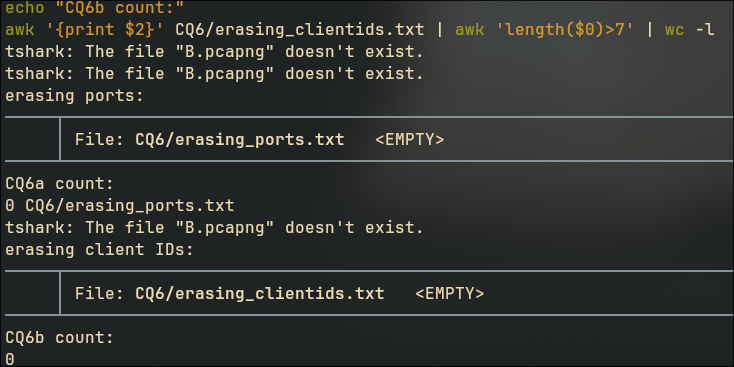

## CQ7
**Question:** How many MQTT subscribe requests directed to the local broker
specify a topic with atleast two wildcards?

**answer:** `9`

**Command used:**
```bash
mkdir -p CQ7

#all subscribe topics to local IPv6 broker
tshark -r B.pcapng -Y "mqtt.msgtype==8 && ipv6.dst==::1" -T fields -e mqtt.topic > CQ7/local_subs.txt
echo "local subscriptions count:"
wc -l CQ7/local_subs.txt
echo "local subscriptions sample:"
head -n 20 CQ7/local_subs.txt

# keep topics with at least two wildcards (+ or #)
grep -E "(\+|#).*(\+|#)" CQ7/local_subs.txt > CQ7/two_wildcards.txt
echo "two wildcards topics:"
cat CQ7/two_wildcards.txt

# count requests
echo "CQ7 count:"
wc -l CQ7/two_wildcards.txt
```

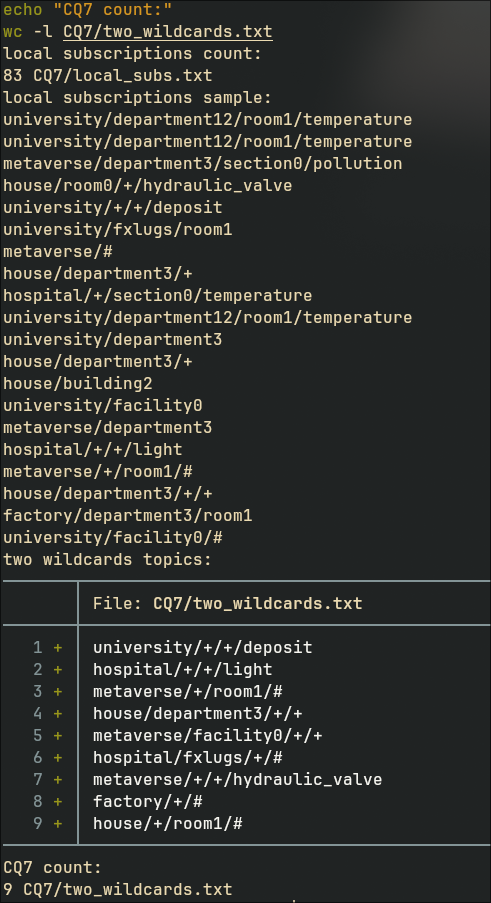

## CQ8
**Question:** Compare the local broker usage in the two capture files A.pcapng and
B.pcapng. The goal is to have a plot on the number of layers of the topics
used in the publish messages directed to the local broker in the two captures.
Produce a histogram plot with number of messages for each number of layers
- Take note of the total number of publish
messages considered for this analysis in the
two captures (all number of layers) -> Report
the two values as CQ8a) CQ8b) in the form

Produce a figure with this behaviour →

- Include commented scripts in the
delivery (if any)
- Include the obtained figure in the report

**answers:**
- CQ8a (A.pcapng): `706`
- CQ8b (B.pcapng): `1269`

**distribution used for the histogram:**
- A: 2 layers -> 264, 3 layers -> 221, 4 layers -> 221
- B: 1 layer -> 42, 2 layers -> 410, 3 layers -> 367, 4 layers -> 450

**Command used:**
```bash
mkdir -p CQ8

#extract local-broker publish topics
tshark -r A.pcapng -Y "mqtt.msgtype==3 && ip.dst==127.0.0.1 && tcp.dstport == 1883" -T fields -e mqtt.topic > CQ8/topics_A_raw.txt
tshark -r B.pcapng -Y "mqtt.msgtype==3 && ipv6.dst==::1 && tcp.dstport == 1883" -T fields -e mqtt.topic > CQ8/topics_B_raw.txt
echo "raw topics A count:"
wc -l CQ8/topics_A_raw.txt
echo "raw topics B count:"
wc -l CQ8/topics_B_raw.txt

#split comma-separated topics (one topic per line)
awk -F ',' '{for(i=1;i<=NF;i++) if($i!="") print $i}' CQ8/topics_A_raw.txt > CQ8/topics_A.txt
awk -F ',' '{for(i=1;i<=NF;i++) if($i!="") print $i}' CQ8/topics_B_raw.txt > CQ8/topics_B.txt

#CQ8a and CQ8b totals
echo "CQ8a total:"
wc -l CQ8/topics_A.txt
echo "CQ8b total:"
wc -l CQ8/topics_B.txt

# layer distributions for histogram
awk -F'/' '{print NF}' CQ8/topics_A.txt | sort | uniq -c > CQ8/layers_A.txt
awk -F'/' '{print NF}' CQ8/topics_B.txt | sort | uniq -c > CQ8/layers_B.txt
echo "layers A:"
cat CQ8/layers_A.txt
echo "layers B:"
cat CQ8/layers_B.txt
```
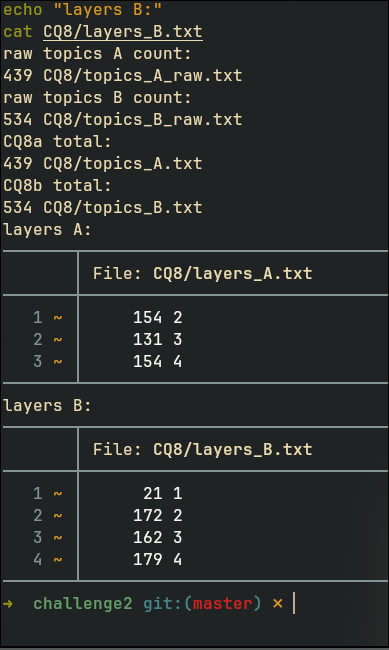

**Important note:** some packets in B contain multiple MQTT publish entries in the same frame; counts above split comma-separated `mqtt.topic` entries so each publish message is counted separately.



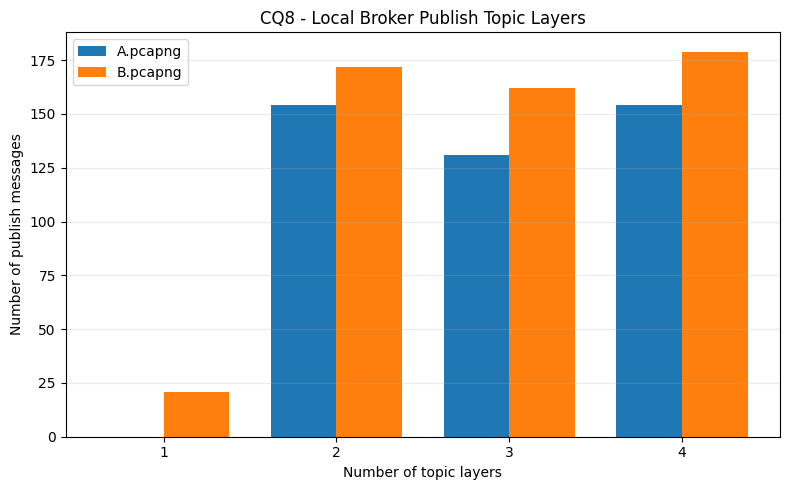

In [16]:
import matplotlib.pyplot as plt

# verified CQ8 distributions
layers_a = {2: 154, 3: 131, 4: 154}
layers_b = {1: 21, 2: 172, 3: 162, 4: 179}

all_layers = sorted(set(layers_a) | set(layers_b))
a_vals = [layers_a.get(k, 0) for k in all_layers]
b_vals = [layers_b.get(k, 0) for k in all_layers]

x = range(len(all_layers))
w = 0.38

plt.figure(figsize=(8, 5))
plt.bar([i - w / 2 for i in x], a_vals, width=w, label='A.pcapng')
plt.bar([i + w / 2 for i in x], b_vals, width=w, label='B.pcapng')
plt.xticks(list(x), all_layers)
plt.xlabel('Number of topic layers')
plt.ylabel('Number of publish messages')
plt.title('CQ8 - Local Broker Publish Topic Layers')
plt.legend()
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()